# Hypothesis Testing — Theory & Real-Life Case Studies

Hypothesis testing is the formal machinery for answering: **"Is what I observed in my sample real, or could it just be random chance?"**

**Contents**
1. Setup
2. The core idea: null vs alternative hypothesis
3. Test statistics, p-values & significance level α
4. Two types of error & statistical power
5. One-tailed vs two-tailed tests
6. The general recipe (5 steps), illustrated by hand
7. One-sample Z-test (known σ)
8. One-sample t-test (unknown σ) — the workhorse test
9. Two-sample t-test: independent groups
10. Paired t-test: before/after on the same subjects
11. Proportion tests (Z-test for one and two proportions)
12. Chi-square test: goodness of fit
13. Chi-square test: independence (contingency tables)
14. ANOVA: comparing more than two group means
15. Confidence intervals vs hypothesis tests (two sides of the same coin)
16. Common pitfalls: p-hacking, multiple testing, misreading p-values
17. Case study 1: A/B testing a website button (proportions)
18. Case study 2: New drug vs placebo (two-sample t-test)
19. Case study 3: Before/after training program (paired t-test)
20. Case study 4: Is a die fair? (chi-square goodness of fit)
21. Case study 5: Smoking and disease (chi-square independence)
22. Case study 6: Comparing four fertilizers (ANOVA)
23. Choosing the right test: decision guide
24. Cheat-sheet, key insights & practice problems

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from math import sqrt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(42)

## 2. The Core Idea: Null vs Alternative Hypothesis

Every hypothesis test starts with two competing claims about a population:

* **Null hypothesis $H_0$**: the "status quo" / "nothing special is happening" / "no effect" / "no difference" claim. We assume it's true unless the data give strong evidence otherwise.
* **Alternative hypothesis $H_1$ (or $H_a$)**: the claim we suspect might be true — an effect, a difference, a change.

**Analogy — a courtroom trial:** $H_0$ = "the defendant is innocent" (assumed true until proven otherwise). $H_1$ = "the defendant is guilty". We only reject $H_0$ ("convict") if the evidence is strong enough — **"beyond reasonable doubt"**, not just "more likely than not". This asymmetry is central to hypothesis testing.

**Important:** we never "prove $H_0$ true" or "prove $H_1$ true". We either:
* **Reject $H_0$** (the data would be too unlikely if $H_0$ were true), or
* **Fail to reject $H_0$** (not enough evidence — this is *not* the same as proving $H_0$ is true; it's like a "not guilty" verdict, not an "innocent" verdict).

In [2]:
examples = pd.DataFrame([
    {"Scenario": "New drug vs placebo",
     "H0": "Drug has no effect (mean improvement = 0)",
     "H1": "Drug has an effect (mean improvement != 0)"},
    {"Scenario": "New website button",
     "H0": "Click rate is the same as the old button",
     "H1": "Click rate is different (or higher)"},
    {"Scenario": "Is a coin fair?",
     "H0": "P(heads) = 0.5",
     "H1": "P(heads) != 0.5"},
    {"Scenario": "Factory quality check",
     "H0": "Mean fill volume = 500 ml (process on target)",
     "H1": "Mean fill volume != 500 ml (process off target)"},
])
print(examples.to_string(index=False))

             Scenario                                            H0                                              H1
  New drug vs placebo     Drug has no effect (mean improvement = 0)      Drug has an effect (mean improvement != 0)
   New website button      Click rate is the same as the old button             Click rate is different (or higher)
      Is a coin fair?                                P(heads) = 0.5                                 P(heads) != 0.5
Factory quality check Mean fill volume = 500 ml (process on target) Mean fill volume != 500 ml (process off target)


## 3. Test Statistics, P-values & Significance Level α

**Test statistic:** a single number computed from the sample that measures "how far" the data are from what $H_0$ predicts (e.g. a Z-score, a t-score, a chi-square value).

**P-value:** *assuming $H_0$ is true*, the probability of observing a test statistic **as extreme as, or more extreme than**, the one actually observed.
* **Small p-value** → the observed data would be surprising under $H_0$ → evidence **against** $H_0$.
* **Large p-value** → the data are quite plausible under $H_0$ → **no strong evidence against** $H_0$.

**Significance level α**: a threshold, chosen *before* looking at the data (commonly 0.05, sometimes 0.01 or 0.10), that defines "how surprising is surprising enough". Decision rule:

$$\text{if } p\text{-value} < \alpha \implies \text{reject } H_0 \qquad\qquad \text{if } p\text{-value} \ge \alpha \implies \text{fail to reject } H_0$$

### ⚠️ What a p-value is NOT
* It is **not** "the probability $H_0$ is true".
* It is **not** "the probability the result is due to chance" (informally people say this, but it is technically the probability of the *data*, given $H_0$, not the probability of $H_0$ given the data).
* A p-value of 0.03 does **not** mean "97% sure $H_1$ is true".

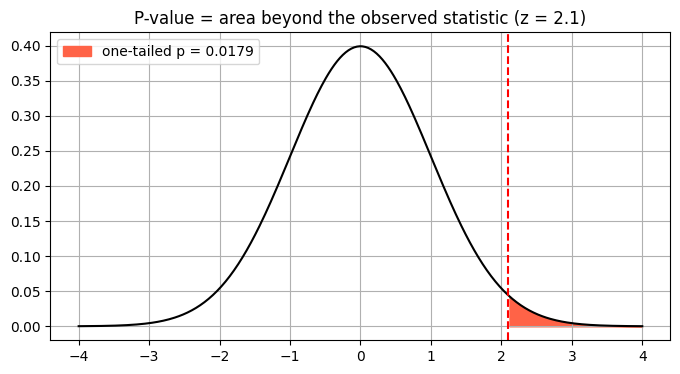

One-tailed p-value  P(Z >= 2.1) = 0.0179
Two-tailed p-value  P(|Z| >= 2.1) = 0.0357


In [3]:
# Illustrate: p-value = area in the tail(s) beyond the observed test statistic
z_obs = 2.1   # example observed z-score
x = np.linspace(-4, 4, 400)

fig, ax = plt.subplots()
ax.plot(x, stats.norm.pdf(x), "k")
ax.fill_between(x, stats.norm.pdf(x), where=(x >= z_obs), color="tomato", label=f"one-tailed p = {stats.norm.sf(z_obs):.4f}")
ax.axvline(z_obs, color="red", ls="--")
ax.set_title(f"P-value = area beyond the observed statistic (z = {z_obs})")
ax.legend(); plt.show()

print(f"One-tailed p-value  P(Z >= {z_obs}) = {stats.norm.sf(z_obs):.4f}")
print(f"Two-tailed p-value  P(|Z| >= {z_obs}) = {2*stats.norm.sf(z_obs):.4f}")

## 4. Two Types of Error & Statistical Power

|  | $H_0$ actually True | $H_0$ actually False |
|---|---|---|
| **Reject $H_0$** | ❌ **Type I error** (false positive), probability = **α** | ✅ Correct (true positive) |
| **Fail to reject $H_0$** | ✅ Correct (true negative) | ❌ **Type II error** (false negative), probability = **β** |

* **α (significance level)** = P(Type I error) = P(reject $H_0$ \| $H_0$ true). We *choose* this before the test.
* **β** = P(Type II error) = P(fail to reject $H_0$ \| $H_0$ false). Depends on the true effect size, sample size, and α.
* **Power = 1 − β** = P(correctly reject $H_0$ \| $H_0$ false) — the test's ability to detect a real effect. We usually want power ≥ 0.80.

**Trade-off:** lowering α (fewer false positives) makes it *harder* to reject $H_0$, which *raises* β (more false negatives) — for a fixed sample size. The only way to reduce **both** is to collect **more data**.

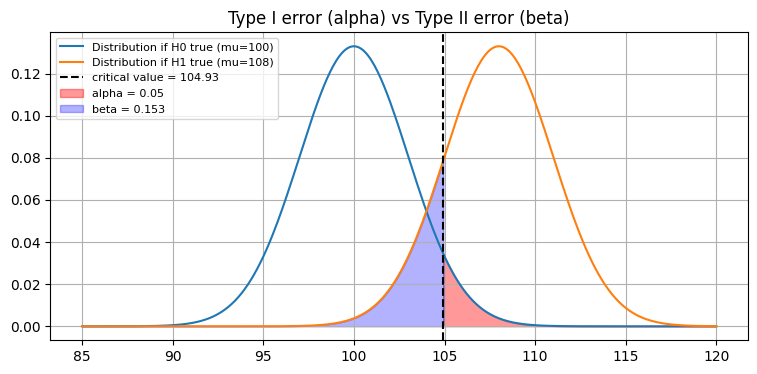

alpha (Type I error rate)  = 0.05
beta  (Type II error rate) = 0.1534
Power (1 - beta)           = 0.8466


In [4]:
# Visualise the trade-off: H0: mu=100 vs H1: mu=108, sigma=15, n=25, one-tailed test
mu0, mu1, sigma, n = 100, 108, 15, 25
se = sigma / sqrt(n)
alpha = 0.05

crit = stats.norm.ppf(1 - alpha, mu0, se)          # critical value (reject if sample mean exceeds this)
beta = stats.norm.cdf(crit, mu1, se)
power = 1 - beta

x = np.linspace(85, 120, 400)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, stats.norm.pdf(x, mu0, se), label="Distribution if H0 true (mu=100)")
ax.plot(x, stats.norm.pdf(x, mu1, se), label="Distribution if H1 true (mu=108)")
ax.axvline(crit, color="k", ls="--", label=f"critical value = {crit:.2f}")
xs_a = np.linspace(crit, 120, 100)
ax.fill_between(xs_a, stats.norm.pdf(xs_a, mu0, se), color="red", alpha=0.4, label=f"alpha = {alpha}")
xs_b = np.linspace(85, crit, 100)
ax.fill_between(xs_b, stats.norm.pdf(xs_b, mu1, se), color="blue", alpha=0.3, label=f"beta = {beta:.3f}")
ax.legend(fontsize=8); ax.set_title("Type I error (alpha) vs Type II error (beta)")
plt.show()

print(f"alpha (Type I error rate)  = {alpha}")
print(f"beta  (Type II error rate) = {beta:.4f}")
print(f"Power (1 - beta)           = {power:.4f}")

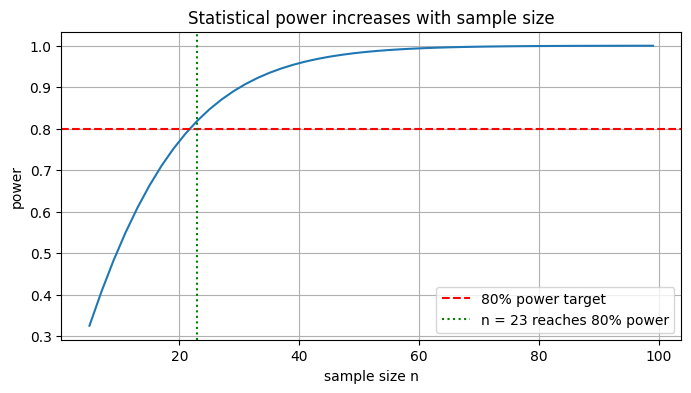

Smallest n for 80% power: 23


In [5]:
# How power changes with sample size (bigger n -> narrower curves -> less overlap -> more power)
ns = np.arange(5, 101, 2)
powers = []
for n_ in ns:
    se_ = sigma / sqrt(n_)
    crit_ = stats.norm.ppf(1 - alpha, mu0, se_)
    powers.append(1 - stats.norm.cdf(crit_, mu1, se_))

plt.plot(ns, powers)
plt.axhline(0.8, color="red", ls="--", label="80% power target")
n_needed = ns[np.argmax(np.array(powers) >= 0.8)]
plt.axvline(n_needed, color="green", ls=":", label=f"n = {n_needed} reaches 80% power")
plt.xlabel("sample size n"); plt.ylabel("power"); plt.legend()
plt.title("Statistical power increases with sample size"); plt.show()
print(f"Smallest n for 80% power: {n_needed}")

## 5. One-Tailed vs Two-Tailed Tests

* **Two-tailed test**: $H_1$: parameter **≠** value. Reject $H_0$ if the statistic is far in **either** direction. Use this by default, and whenever "different in any direction" is the real question.
* **One-tailed test**: $H_1$: parameter **>** value (or **<** value). Only used when you have a specific directional question decided **before** seeing the data (e.g. "does the new process increase output?"). It gives more power to detect an effect in that one direction, but zero power for the other.

⚠️ **Don't decide one-tailed vs two-tailed after peeking at the data** — that inflates your true error rate (a form of p-hacking, Section 16).

Two-tailed p-value: 0.0719
One-tailed p-value (H1: mu > mu0): 0.0359
One-tailed p-value (H1: mu < mu0): 0.9641


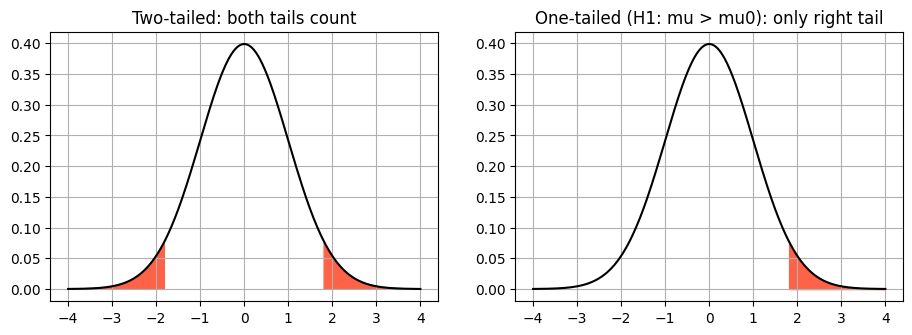

In [6]:
z = 1.8
print("Two-tailed p-value:", round(2 * stats.norm.sf(abs(z)), 4))
print("One-tailed p-value (H1: mu > mu0):", round(stats.norm.sf(z), 4))
print("One-tailed p-value (H1: mu < mu0):", round(stats.norm.cdf(z), 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
x = np.linspace(-4, 4, 400)
axes[0].plot(x, stats.norm.pdf(x), "k")
axes[0].fill_between(x, stats.norm.pdf(x), where=(np.abs(x) >= z), color="tomato")
axes[0].set_title("Two-tailed: both tails count")
axes[1].plot(x, stats.norm.pdf(x), "k")
axes[1].fill_between(x, stats.norm.pdf(x), where=(x >= z), color="tomato")
axes[1].set_title("One-tailed (H1: mu > mu0): only right tail")
plt.show()

## 6. The General Recipe (5 Steps)

1. **State $H_0$ and $H_1$** (and pick one- or two-tailed, before seeing the data).
2. **Choose α** (usually 0.05).
3. **Compute the test statistic** from the sample.
4. **Compute the p-value** (or compare the statistic to a critical value).
5. **Decide**: if p-value < α, reject $H_0$; otherwise, fail to reject $H_0$. State the conclusion **in context**.

### Worked toy example (by hand, then with scipy)
A cereal box is labelled "500 g". A regulator suspects boxes are **under**-filled. They weigh 25 boxes: sample mean $\bar x = 496$ g. Historically, σ = 12 g (known). Test at α = 0.05.

$H_0: \mu = 500$ vs $H_1: \mu < 500$ (one-tailed — the regulator specifically suspects under-filling).

In [7]:
mu0, xbar, sigma, n, alpha = 500, 496, 12, 25, 0.05

# Step 3: test statistic (Z, since sigma is known)
z = (xbar - mu0) / (sigma / sqrt(n))
print("Step 3. Test statistic z =", round(z, 4))

# Step 4: p-value (one-tailed, left side because H1: mu < 500)
p_value = stats.norm.cdf(z)
print("Step 4. p-value =", round(p_value, 4))

# Step 5: decision
print("Step 5.", "REJECT H0" if p_value < alpha else "FAIL TO REJECT H0",
      f"(p={p_value:.4f} vs alpha={alpha})")
print("\nConclusion: there IS statistically significant evidence that boxes are under-filled on average."
      if p_value < alpha else "\nConclusion: not enough evidence to conclude under-filling.")

Step 3. Test statistic z = -1.6667
Step 4. p-value = 0.0478
Step 5. REJECT H0 (p=0.0478 vs alpha=0.05)

Conclusion: there IS statistically significant evidence that boxes are under-filled on average.


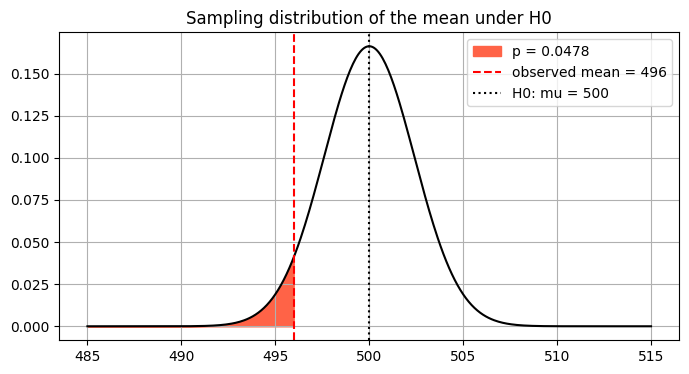

In [8]:
# Cross-check with scipy's built-in ztest-equivalent (statsmodels not always available, so compute manually + visualize)
x = np.linspace(485, 515, 400)
fig, ax = plt.subplots()
ax.plot(x, stats.norm.pdf(x, mu0, sigma/sqrt(n)), "k")
ax.fill_between(x, stats.norm.pdf(x, mu0, sigma/sqrt(n)), where=(x <= xbar), color="tomato", label=f"p = {p_value:.4f}")
ax.axvline(xbar, color="red", ls="--", label=f"observed mean = {xbar}")
ax.axvline(mu0, color="k", ls=":", label=f"H0: mu = {mu0}")
ax.legend(); ax.set_title("Sampling distribution of the mean under H0"); plt.show()

## 7. One-Sample Z-Test (σ known)

Use when testing a population mean **and the population standard deviation σ is known** (rare in practice, but foundational, and a good approximation when n is large).

$$Z=\frac{\bar x-\mu_0}{\sigma/\sqrt n}\ \sim\ N(0,1)\text{ under }H_0$$

In [9]:
def z_test_mean(xbar, mu0, sigma, n, alternative="two-sided"):
    z = (xbar - mu0) / (sigma / sqrt(n))
    if alternative == "two-sided":
        p = 2 * stats.norm.sf(abs(z))
    elif alternative == "greater":
        p = stats.norm.sf(z)
    else:  # "less"
        p = stats.norm.cdf(z)
    return z, p

z, p = z_test_mean(xbar=103, mu0=100, sigma=15, n=40, alternative="two-sided")
print(f"z = {z:.4f}, p = {p:.4f}")

z = 1.2649, p = 0.2059


## 8. One-Sample t-Test (σ unknown) — the Workhorse Test

In practice we almost never know the true σ — we estimate it from the sample (s). This adds extra uncertainty, so we use the **t-distribution** (which has heavier tails than Normal, especially for small n) instead of Z.

$$t=\frac{\bar x-\mu_0}{s/\sqrt n}\ \sim\ t_{\,n-1}\text{ under }H_0$$

Degrees of freedom = n − 1. As n grows, $t_{n-1}\to N(0,1)$ (t and Z become nearly identical for n ≳ 30).

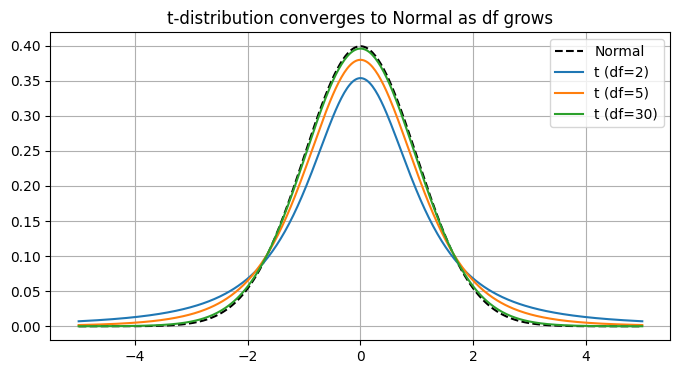

In [10]:
# t-distribution has heavier tails than Normal, especially for small df
x = np.linspace(-5, 5, 400)
plt.plot(x, stats.norm.pdf(x), "k--", label="Normal")
for df in (2, 5, 30):
    plt.plot(x, stats.t.pdf(x, df), label=f"t (df={df})")
plt.legend(); plt.title("t-distribution converges to Normal as df grows"); plt.show()

In [11]:
# Example: a machine should dispense 250 ml. Sample of 15 pours.
sample = np.array([248, 252, 249, 251, 247, 253, 250, 246, 252, 249, 251, 248, 250, 254, 249])
mu0 = 250

t_stat, p_value = stats.ttest_1samp(sample, mu0)
print(f"n = {len(sample)}, mean = {sample.mean():.2f}, sd = {sample.std(ddof=1):.3f}")
print(f"t-statistic = {t_stat:.4f}, df = {len(sample)-1}, two-tailed p-value = {p_value:.4f}")
print("Decision at alpha=0.05:", "REJECT H0 (mean differs from 250)" if p_value < 0.05 else "FAIL TO REJECT H0 (no evidence of a difference)")

# Manual calculation, to show what scipy is doing internally
xbar, s, n = sample.mean(), sample.std(ddof=1), len(sample)
t_manual = (xbar - mu0) / (s / sqrt(n))
p_manual = 2 * stats.t.sf(abs(t_manual), df=n-1)
print(f"\nManual check: t = {t_manual:.4f}, p = {p_manual:.4f}  (matches scipy)")

n = 15, mean = 249.93, sd = 2.251
t-statistic = -0.1147, df = 14, two-tailed p-value = 0.9103
Decision at alpha=0.05: FAIL TO REJECT H0 (no evidence of a difference)

Manual check: t = -0.1147, p = 0.9103  (matches scipy)


## 9. Two-Sample t-Test: Independent Groups

Compares the means of **two separate, independent** groups (e.g. treatment vs control, method A vs method B).

$$H_0:\mu_1=\mu_2\qquad H_1:\mu_1\ne\mu_2\ (\text{or} >, <)$$

**Welch's t-test** (does *not* assume equal variances — the safer default) vs the classic **pooled/Student's t-test** (assumes equal variances). Welch's is recommended unless you have good reason to believe variances are equal.

In [12]:
group_A = rng.normal(50, 8, 30)      # e.g. test scores, method A
group_B = rng.normal(55, 9, 32)      # method B

t_welch, p_welch = stats.ttest_ind(group_A, group_B, equal_var=False)   # Welch's (default-safe)
t_pool,  p_pool  = stats.ttest_ind(group_A, group_B, equal_var=True)    # classic pooled

print(f"Group A: n={len(group_A)}, mean={group_A.mean():.2f}, sd={group_A.std(ddof=1):.2f}")
print(f"Group B: n={len(group_B)}, mean={group_B.mean():.2f}, sd={group_B.std(ddof=1):.2f}")
print(f"\nWelch's t-test  : t = {t_welch:.4f}, p = {p_welch:.4f}")
print(f"Pooled t-test   : t = {t_pool:.4f}, p = {p_pool:.4f}")

# Check the equal-variance assumption with Levene's test
lev_stat, lev_p = stats.levene(group_A, group_B)
print(f"\nLevene's test for equal variances: p = {lev_p:.4f}",
      "-> variances look similar, pooled OK too" if lev_p > 0.05 else "-> variances differ, prefer Welch's")

Group A: n=30, mean=50.13, sd=6.21
Group B: n=32, mean=55.39, sd=7.59

Welch's t-test  : t = -2.9922, p = 0.0040
Pooled t-test   : t = -2.9729, p = 0.0042

Levene's test for equal variances: p = 0.2796 -> variances look similar, pooled OK too


/tmp/ipykernel_155/1929551698.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([group_A, group_B], labels=["Method A", "Method B"])


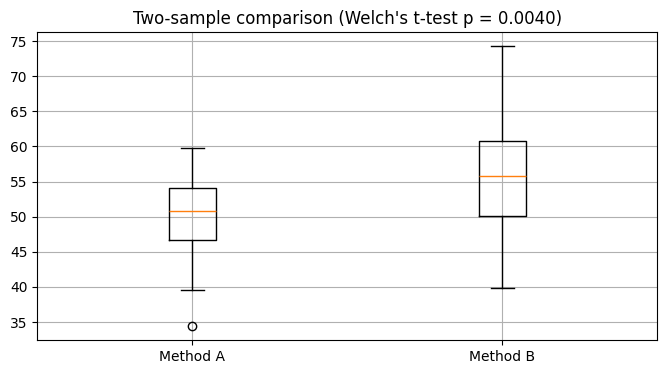

In [13]:
fig, ax = plt.subplots()
ax.boxplot([group_A, group_B], labels=["Method A", "Method B"])
ax.set_title(f"Two-sample comparison (Welch's t-test p = {p_welch:.4f})")
plt.show()

## 10. Paired t-Test: Before / After on the Same Subjects

Used when the **same** subjects are measured **twice** (before/after, left/right, matched pairs) — the two sets of measurements are **not independent**. We test the mean of the **differences**.

$$d_i=x_{i,\text{after}}-x_{i,\text{before}}\qquad H_0:\mu_d=0$$

This is really just a **one-sample t-test on the differences** — and it's more powerful than treating before/after as two independent groups, because it removes person-to-person variability.

In [14]:
rng2 = np.random.default_rng(5)
before = rng2.normal(70, 10, 20)
after  = before + rng2.normal(4, 5, 20)          # true average improvement of +4

t_paired, p_paired = stats.ttest_rel(after, before)
diffs = after - before
print(f"Mean difference (after - before) = {diffs.mean():.3f}, sd of diffs = {diffs.std(ddof=1):.3f}")
print(f"Paired t-test: t = {t_paired:.4f}, p = {p_paired:.6f}")

# Compare: what if we (incorrectly) treated this as two independent groups?
t_indep, p_indep = stats.ttest_ind(after, before)
print(f"\n(For comparison) treating as independent groups: t = {t_indep:.4f}, p = {p_indep:.4f}")
print("Paired test is more POWERFUL here because it removes person-to-person variability.")

Mean difference (after - before) = 1.747, sd of diffs = 3.449
Paired t-test: t = 2.2651, p = 0.035388

(For comparison) treating as independent groups: t = 0.5569, p = 0.5809
Paired test is more POWERFUL here because it removes person-to-person variability.


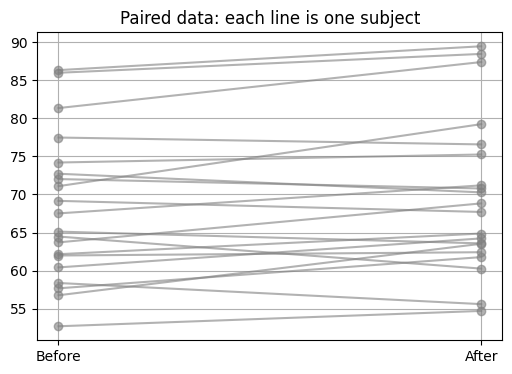

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
for b, a in zip(before, after):
    ax.plot([0, 1], [b, a], "o-", color="gray", alpha=0.6)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Before", "After"])
ax.set_title("Paired data: each line is one subject"); plt.show()

## 11. Proportion Tests (Z-tests for Proportions)

For **categorical** yes/no outcomes (conversion rates, defect rates, approval rates), we test **proportions**, using the fact that a sample proportion is approximately Normal for large n (via CLT on the underlying Binomial).

### One-sample proportion test
$$H_0: p=p_0 \qquad Z=\frac{\hat p-p_0}{\sqrt{p_0(1-p_0)/n}}$$

### Two-sample proportion test (e.g. A/B testing)
$$H_0: p_1=p_2 \qquad Z=\frac{\hat p_1-\hat p_2}{\sqrt{\hat p(1-\hat p)\left(\frac1{n_1}+\frac1{n_2}\right)}}, \quad \hat p=\frac{x_1+x_2}{n_1+n_2}\ (\text{pooled proportion})$$

In [16]:
def one_prop_ztest(x, n, p0, alternative="two-sided"):
    p_hat = x / n
    se = sqrt(p0 * (1 - p0) / n)
    z = (p_hat - p0) / se
    if alternative == "two-sided":
        p = 2 * stats.norm.sf(abs(z))
    elif alternative == "greater":
        p = stats.norm.sf(z)
    else:
        p = stats.norm.cdf(z)
    return z, p

def two_prop_ztest(x1, n1, x2, n2, alternative="two-sided"):
    p1, p2 = x1/n1, x2/n2
    p_pool = (x1 + x2) / (n1 + n2)
    se = sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    if se == 0:
        return 0.0, 1.0
    z = (p1 - p2) / se
    if alternative == "two-sided":
        p = 2 * stats.norm.sf(abs(z))
    elif alternative == "greater":
        p = stats.norm.sf(z)
    else:
        p = stats.norm.cdf(z)
    return z, p

# One-proportion example: is a coin fair? 58 heads out of 100 flips
z, p = one_prop_ztest(58, 100, 0.5)
print(f"One-proportion test (coin fairness): z = {z:.4f}, p = {p:.4f}")

# Two-proportion example: conversion rates
z2, p2 = two_prop_ztest(x1=45, n1=500, x2=63, n2=520)
print(f"Two-proportion test (conversion A vs B): z = {z2:.4f}, p = {p2:.4f}")

One-proportion test (coin fairness): z = 1.6000, p = 0.1096


Two-proportion test (conversion A vs B): z = -1.6165, p = 0.1060


## 12. Chi-Square Test: Goodness of Fit

Tests whether **observed category counts** match an **expected/theoretical distribution**.

$$\chi^2=\sum_i\frac{(O_i-E_i)^2}{E_i}\ \sim\ \chi^2_{k-1}$$

where $O_i$ = observed count, $E_i$ = expected count under $H_0$, k = number of categories.

**Assumption:** expected count in each category should be ≥ 5 (pool categories together if not).

Observed: [15 22 17 25 19 22]
Expected: [20. 20. 20. 20. 20. 20.]
chi-square = 3.4000, df = 5, p-value = 0.6386
Decision: FAIL TO REJECT H0 (no evidence die is unfair)


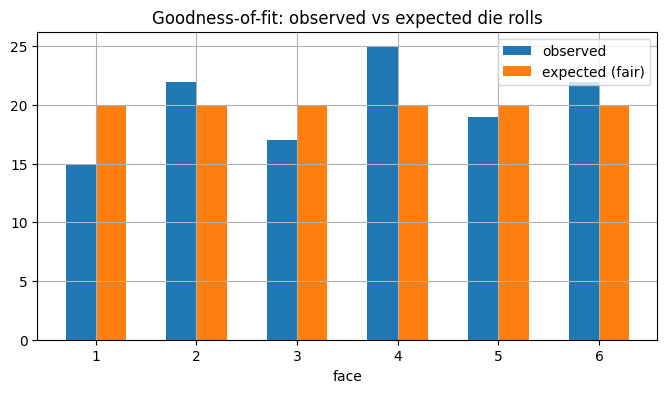

In [17]:
# Example: is a die fair? Roll it 120 times.
observed = np.array([15, 22, 17, 25, 19, 22])       # observed counts for faces 1-6
n_total = observed.sum()
expected = np.full(6, n_total / 6)                    # 20 each if fair

chi2, p = stats.chisquare(observed, expected)
print(f"Observed: {observed}")
print(f"Expected: {expected}")
print(f"chi-square = {chi2:.4f}, df = {len(observed)-1}, p-value = {p:.4f}")
print("Decision:", "REJECT H0 (die is NOT fair)" if p < 0.05 else "FAIL TO REJECT H0 (no evidence die is unfair)")

plt.bar(np.arange(1,7) - 0.15, observed, width=0.3, label="observed")
plt.bar(np.arange(1,7) + 0.15, expected, width=0.3, label="expected (fair)")
plt.legend(); plt.xlabel("face"); plt.title("Goodness-of-fit: observed vs expected die rolls"); plt.show()

## 13. Chi-Square Test: Independence (Contingency Tables)

Tests whether **two categorical variables are associated**, using a **contingency table** of counts.

$$H_0:\text{the two variables are independent}\qquad E_{ij}=\frac{(\text{row}_i\text{ total})\times(\text{col}_j\text{ total})}{\text{grand total}}$$

In [18]:
# Example: is preferred product category associated with age group?
table = pd.DataFrame(
    [[50, 30, 20],
     [25, 45, 30],
     [15, 25, 60]],
    index=["18-30", "31-50", "51+"],
    columns=["Electronics", "Clothing", "Home Goods"]
)
print("Observed counts:\n", table, "\n")

chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"chi-square = {chi2:.4f}, df = {dof}, p-value = {p:.6f}")
print("\nExpected counts under independence:\n", pd.DataFrame(expected.round(1), index=table.index, columns=table.columns))
print("\nDecision:", "REJECT H0 (age group and category ARE associated)" if p < 0.05 else "FAIL TO REJECT H0 (no evidence of association)")

# Effect size: Cramer's V (0 = no association, 1 = perfect association)
n_total = table.values.sum()
r, c = table.shape
cramers_v = sqrt(chi2 / (n_total * (min(r, c) - 1)))
print(f"\nCramer's V (effect size) = {cramers_v:.3f}")

Observed counts:
        Electronics  Clothing  Home Goods
18-30           50        30          20
31-50           25        45          30
51+             15        25          60 

chi-square = 51.8030, df = 4, p-value = 0.000000

Expected counts under independence:
        Electronics  Clothing  Home Goods
18-30         30.0      33.3        36.7
31-50         30.0      33.3        36.7
51+           30.0      33.3        36.7

Decision: REJECT H0 (age group and category ARE associated)

Cramer's V (effect size) = 0.294


## 14. ANOVA: Comparing More Than Two Group Means

**ANOVA (Analysis of Variance)** tests whether **3 or more** group means are all equal, without inflating the false-positive rate that would come from running many pairwise t-tests.

$$H_0:\mu_1=\mu_2=\dots=\mu_k\qquad H_1:\text{at least one mean differs}$$

It compares **variance between groups** to **variance within groups** using an F-statistic. A significant ANOVA tells you *some* group differs, but not *which* — follow up with **post-hoc tests** (e.g. Tukey's HSD) to find out.

**Why not just run many t-tests?** Each test at α=0.05 has a 5% false-positive chance; run enough pairwise tests and the *overall* chance of at least one false positive balloons (Section 16). ANOVA controls this with a single test.

F-statistic = 13.2187, p-value = 0.00001
Decision: REJECT H0 (at least one fertilizer differs)

Group means:
 A    19.91
B    22.08
C    24.88
D    19.34
dtype: float64


/tmp/ipykernel_155/3269241358.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fert_A, fert_B, fert_C, fert_D], labels=["A", "B", "C", "D"])


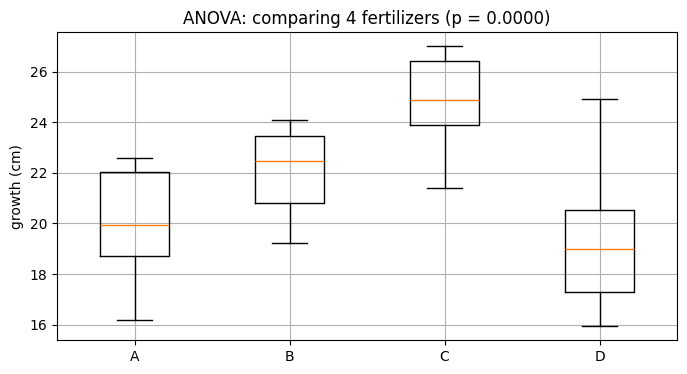

In [19]:
# Example: 4 fertilizers, plant growth (cm) measured on 10 plants each
fert_A = rng.normal(20, 3, 10)
fert_B = rng.normal(22, 3, 10)
fert_C = rng.normal(25, 3, 10)
fert_D = rng.normal(21, 3, 10)

f_stat, p_value = stats.f_oneway(fert_A, fert_B, fert_C, fert_D)
print(f"F-statistic = {f_stat:.4f}, p-value = {p_value:.5f}")
print("Decision:", "REJECT H0 (at least one fertilizer differs)" if p_value < 0.05 else "FAIL TO REJECT H0")

groups = pd.DataFrame({"A": fert_A, "B": fert_B, "C": fert_C, "D": fert_D})
print("\nGroup means:\n", groups.mean().round(2))

plt.boxplot([fert_A, fert_B, fert_C, fert_D], labels=["A", "B", "C", "D"])
plt.title(f"ANOVA: comparing 4 fertilizers (p = {p_value:.4f})"); plt.ylabel("growth (cm)"); plt.show()

In [20]:
# Post-hoc: Tukey's HSD to find WHICH pairs differ
from itertools import combinations

all_data = np.concatenate([fert_A, fert_B, fert_C, fert_D])
labels = np.repeat(["A", "B", "C", "D"], 10)

try:
    from scipy.stats import tukey_hsd
    res = tukey_hsd(fert_A, fert_B, fert_C, fert_D)
    print(res)
except ImportError:
    # fallback: pairwise t-tests with Bonferroni correction
    pairs = list(combinations(["A", "B", "C", "D"], 2))
    data = {"A": fert_A, "B": fert_B, "C": fert_C, "D": fert_D}
    m = len(pairs)
    print(f"Bonferroni-corrected pairwise comparisons (alpha/{m} = {0.05/m:.4f} each):")
    for g1, g2 in pairs:
        t, p = stats.ttest_ind(data[g1], data[g2])
        print(f"  {g1} vs {g2}: p = {p:.4f}  {'SIGNIFICANT' if p < 0.05/m else ''}")

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -2.166     0.138    -4.797     0.465
 (0 - 2)     -4.965     0.000    -7.596    -2.334
 (0 - 3)      0.573     0.936    -2.058     3.203
 (1 - 0)      2.166     0.138    -0.465     4.797
 (1 - 2)     -2.799     0.033    -5.430    -0.169
 (1 - 3)      2.739     0.039     0.108     5.369
 (2 - 0)      4.965     0.000     2.334     7.596
 (2 - 1)      2.799     0.033     0.169     5.430
 (2 - 3)      5.538     0.000     2.907     8.168
 (3 - 0)     -0.573     0.936    -3.203     2.058
 (3 - 1)     -2.739     0.039    -5.369    -0.108
 (3 - 2)     -5.538     0.000    -8.168    -2.907



## 15. Confidence Intervals vs Hypothesis Tests: Two Sides of the Same Coin

A **two-sided hypothesis test at level α** and a **(1−α) confidence interval** are directly linked:

> **Reject $H_0:\mu=\mu_0$ at level α ⟺ $\mu_0$ lies outside the (1−α) confidence interval for μ.**

Confidence intervals are often *more informative* than a bare p-value: they show the **size** and **direction** of an effect, not just whether it's "significant".

In [21]:
sample = np.array([248, 252, 249, 251, 247, 253, 250, 246, 252, 249, 251, 248, 250, 254, 249])
mu0 = 250
xbar, s, n = sample.mean(), sample.std(ddof=1), len(sample)

ci = stats.t.interval(0.95, df=n-1, loc=xbar, scale=s/sqrt(n))
t_stat, p_value = stats.ttest_1samp(sample, mu0)

print(f"Sample mean = {xbar:.2f}")
print(f"95% CI for the true mean = ({ci[0]:.2f}, {ci[1]:.2f})")
print(f"Does the CI contain mu0={mu0}? {'Yes' if ci[0] <= mu0 <= ci[1] else 'No'}")
print(f"t-test p-value = {p_value:.4f}  (alpha=0.05)")
print("Consistent?", "Yes - CI contains mu0 AND we fail to reject H0" if (ci[0] <= mu0 <= ci[1]) == (p_value >= 0.05) else "Mismatch!")

Sample mean = 249.93
95% CI for the true mean = (248.69, 251.18)
Does the CI contain mu0=250? Yes
t-test p-value = 0.9103  (alpha=0.05)
Consistent? Yes - CI contains mu0 AND we fail to reject H0


## 16. Common Pitfalls

### 16.1 P-hacking / data dredging
Trying many tests, subgroups, or variables until *something* is significant (p < 0.05), then reporting only that. With enough attempts, false positives are almost guaranteed even if $H_0$ is always true.

In [22]:
# Simulate p-hacking: test 20 "variables" that are actually pure noise (H0 always true)
alpha = 0.05
n_tests = 20
p_values = []
for i in range(n_tests):
    noise_group1 = rng.normal(0, 1, 30)
    noise_group2 = rng.normal(0, 1, 30)     # truly no difference
    _, p = stats.ttest_ind(noise_group1, noise_group2)
    p_values.append(p)

significant = sum(p < alpha for p in p_values)
print(f"Out of {n_tests} tests on PURE NOISE (H0 always true), {significant} came out 'significant' at alpha=0.05")
print("Expected false positives by chance alone:", round(n_tests * alpha, 1))
print("\nIf you only reported the 'significant' ones, you'd wrongly claim a real effect!")

Out of 20 tests on PURE NOISE (H0 always true), 1 came out 'significant' at alpha=0.05
Expected false positives by chance alone: 1.0

If you only reported the 'significant' ones, you'd wrongly claim a real effect!


### 16.2 The multiple-testing problem, and the Bonferroni correction

If you genuinely need to run **m** independent tests, the chance of **at least one** false positive (family-wise error rate) is:
$$1-(1-\alpha)^m$$
The simple **Bonferroni correction** controls this by testing each comparison at $\alpha/m$ instead of α.

In [23]:
for m in (1, 5, 10, 20, 50):
    fwer = 1 - (1 - 0.05)**m
    print(f"m = {m:2d} tests: chance of >= 1 false positive = {fwer:.1%}   (Bonferroni alpha per test = {0.05/m:.4f})")

m =  1 tests: chance of >= 1 false positive = 5.0%   (Bonferroni alpha per test = 0.0500)
m =  5 tests: chance of >= 1 false positive = 22.6%   (Bonferroni alpha per test = 0.0100)
m = 10 tests: chance of >= 1 false positive = 40.1%   (Bonferroni alpha per test = 0.0050)
m = 20 tests: chance of >= 1 false positive = 64.2%   (Bonferroni alpha per test = 0.0025)
m = 50 tests: chance of >= 1 false positive = 92.3%   (Bonferroni alpha per test = 0.0010)


### 16.3 Statistical significance ≠ practical significance
With a **huge sample size**, even a *tiny, meaningless* difference can become "statistically significant" (p < 0.05). Always look at the **effect size** (e.g. the actual difference in means, or Cohen's d), not just the p-value.

### 16.4 "Failing to reject $H_0$" is not proof $H_0$ is true
It may simply mean the sample was too small to detect a real (but small) effect — i.e. **low power**. Absence of evidence is not evidence of absence.

In [24]:
# Demonstrate: huge n makes a trivially small difference 'significant'
np.random.seed(1)
big_A = rng.normal(50.00, 10, 100_000)
big_B = rng.normal(50.05, 10, 100_000)     # a difference of 0.05 -- practically meaningless

t, p = stats.ttest_ind(big_A, big_B)
diff = big_B.mean() - big_A.mean()
pooled_sd = sqrt((big_A.var(ddof=1) + big_B.var(ddof=1)) / 2)
cohens_d = diff / pooled_sd

print(f"Difference in means: {diff:.4f}  (tiny, real-world meaningless)")
print(f"t = {t:.3f}, p = {p:.5f}  -> 'statistically significant'!")
print(f"Cohen's d (effect size) = {cohens_d:.4f}  -> essentially ZERO practical effect")
print("\nLesson: with n=100,000 per group, even noise-level differences look 'significant'. ALWAYS check effect size too.")

Difference in means: 0.1103  (tiny, real-world meaningless)
t = -2.460, p = 0.01388  -> 'statistically significant'!
Cohen's d (effect size) = 0.0110  -> essentially ZERO practical effect

Lesson: with n=100,000 per group, even noise-level differences look 'significant'. ALWAYS check effect size too.


---
# Real-Life Case Studies
---

## 17. Case Study 1: A/B Testing a Website "Buy Now" Button

An e-commerce team tests a new button color. **Control** (old blue button): 45 conversions out of 500 visitors. **Treatment** (new green button): 63 conversions out of 520 visitors.

**Questions**
1. Is the difference in conversion rate statistically significant at α = 0.05?
2. What's the 95% confidence interval for the *difference* in conversion rates?
3. Is the improvement *practically* meaningful (in extra revenue), assuming an average order value of ₹800 and 50,000 monthly visitors?
4. If the team ran this test, peeked daily, and stopped as soon as p < 0.05 (rather than fixing the sample size in advance), how could that mislead them?

In [25]:
x1, n1 = 45, 500     # control
x2, n2 = 63, 520      # treatment
p1, p2 = x1/n1, x2/n2

z, p_value = two_prop_ztest(x1, n1, x2, n2, alternative="two-sided")
print(f"1. Control conversion rate  = {p1:.2%}")
print(f"   Treatment conversion rate = {p2:.2%}")
print(f"   z = {z:.4f}, two-tailed p-value = {p_value:.4f}")
print("   Decision:", "REJECT H0 - the difference IS statistically significant" if p_value < 0.05 else "FAIL TO REJECT H0 - not enough evidence of a real difference")

1. Control conversion rate  = 9.00%
   Treatment conversion rate = 12.12%
   z = -1.6165, two-tailed p-value = 0.1060
   Decision: FAIL TO REJECT H0 - not enough evidence of a real difference


In [26]:
# 2. CI for the difference in proportions
diff = p2 - p1
se_diff = sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
z_crit = stats.norm.ppf(0.975)
ci_lo, ci_hi = diff - z_crit*se_diff, diff + z_crit*se_diff
print(f"2. Difference in conversion rate = {diff:.2%}")
print(f"   95% CI for the difference = ({ci_lo:.2%}, {ci_hi:.2%})")

# 3. Business impact
aov, visitors = 800, 50_000
extra_conversions = visitors * diff
extra_revenue = extra_conversions * aov
print(f"\n3. At {visitors:,} visitors/month, the extra conversion rate translates to about {extra_conversions:.0f} more orders")
print(f"   Estimated extra monthly revenue = Rs {extra_revenue:,.0f}")
print(f"   Using the CI bounds: between Rs {visitors*ci_lo*aov:,.0f} and Rs {visitors*ci_hi*aov:,.0f} per month")

2. Difference in conversion rate = 3.12%
   95% CI for the difference = (-0.65%, 6.88%)

3. At 50,000 visitors/month, the extra conversion rate translates to about 1558 more orders
   Estimated extra monthly revenue = Rs 1,246,154
   Using the CI bounds: between Rs -258,937 and Rs 2,751,244 per month


In [27]:
# 4. Simulate the danger of "peeking" (optional stopping) under a TRUE null (no real difference)
alpha = 0.05
false_positive_with_peeking = 0
n_simulations = 2000
max_n_per_day = 20
days = 30

for sim in range(n_simulations):
    c_conv, c_n, t_conv, t_n = 0, 0, 0, 0
    stopped_significant = False
    for day in range(days):
        c_conv += rng.binomial(max_n_per_day, 0.09)   # true rate same for both (9%)
        c_n += max_n_per_day
        t_conv += rng.binomial(max_n_per_day, 0.09)
        t_n += max_n_per_day
        if c_n > 30 and t_n > 30:
            _, p_peek = two_prop_ztest(c_conv, c_n, t_conv, t_n)
            if p_peek < alpha:
                stopped_significant = True
                break
    if stopped_significant:
        false_positive_with_peeking += 1

print(f"4. With daily peeking and stopping early (TRUE null, no real difference):")
print(f"   False-positive rate = {false_positive_with_peeking/n_simulations:.1%}  (should be ~5% if tested only ONCE)")
print("   -> Peeking repeatedly and stopping at the first 'significant' result inflates false positives far above the nominal alpha!")

4. With daily peeking and stopping early (TRUE null, no real difference):
   False-positive rate = 24.2%  (should be ~5% if tested only ONCE)
   -> Peeking repeatedly and stopping at the first 'significant' result inflates false positives far above the nominal alpha!


### 💡 Insights (Case Study 1)
* Here the green button shows a **higher point-estimate conversion rate**, but the difference is **not statistically significant** at this sample size (p ≈ 0.11 > 0.05) — we fail to reject $H_0$. The confidence interval for the difference actually crosses zero (roughly −0.6% to +6.9%), which is exactly what "not significant" looks like: the data can't rule out "no real difference" or even a small drop.
* This is a useful, realistic outcome: a promising-looking lift in a small sample is often **not yet proof** of a real effect. The business shouldn't roll out the change (or kill it) based on this test alone — it should either **collect more data** or run a proper power calculation to see how large a sample would be needed to detect a lift of this size reliably.
* **"Peek and stop" testing is a real, common mistake** that silently inflates the false-positive rate well past 5% — the simulation shows it can push the true error rate several times higher. Fix the sample size (or use proper sequential-testing methods) *before* starting the experiment, rather than stopping as soon as a result looks favourable.

## 18. Case Study 2: New Drug vs Placebo (Two-Sample t-Test)

A clinical trial measures **blood pressure reduction (mmHg)** after 8 weeks: 35 patients get the new drug, 35 get a placebo.

**Questions**
1. Does the drug significantly reduce blood pressure more than placebo?
2. What is the effect size (Cohen's d), and how should we describe the magnitude in plain language?
3. What sample size would have been needed to detect a smaller, more realistic effect (say, half the observed size) with 80% power?

In [28]:
drug_group = rng.normal(8.5, 5, 35)       # mean reduction 8.5 mmHg
placebo_group = rng.normal(4.0, 5, 35)    # mean reduction 4.0 mmHg (placebo effect)

t_stat, p_value = stats.ttest_ind(drug_group, placebo_group, equal_var=False)
print(f"1. Drug group   : mean reduction = {drug_group.mean():.2f} mmHg, sd = {drug_group.std(ddof=1):.2f}")
print(f"   Placebo group: mean reduction = {placebo_group.mean():.2f} mmHg, sd = {placebo_group.std(ddof=1):.2f}")
print(f"   t = {t_stat:.4f}, p = {p_value:.5f}")
print("   Decision:", "REJECT H0 - drug shows a significant additional effect" if p_value < 0.05 else "FAIL TO REJECT H0")

1. Drug group   : mean reduction = 9.39 mmHg, sd = 5.27
   Placebo group: mean reduction = 2.36 mmHg, sd = 4.81
   t = 5.8261, p = 0.00000
   Decision: REJECT H0 - drug shows a significant additional effect


In [29]:
# 2. Effect size: Cohen's d
diff = drug_group.mean() - placebo_group.mean()
pooled_sd = sqrt(((len(drug_group)-1)*drug_group.var(ddof=1) + (len(placebo_group)-1)*placebo_group.var(ddof=1))
                 / (len(drug_group) + len(placebo_group) - 2))
d = diff / pooled_sd
print(f"2. Mean difference = {diff:.2f} mmHg, Cohen's d = {d:.3f}")

def interpret_d(d):
    ad = abs(d)
    if ad < 0.2: return "negligible"
    if ad < 0.5: return "small"
    if ad < 0.8: return "medium"
    return "large"
print(f"   Interpretation: a '{interpret_d(d)}' effect size (rule of thumb: 0.2/0.5/0.8 = small/medium/large)")

2. Mean difference = 7.03 mmHg, Cohen's d = 1.393
   Interpretation: a 'large' effect size (rule of thumb: 0.2/0.5/0.8 = small/medium/large)


In [30]:
# 3. Sample size needed for a SMALLER, more realistic effect (half the size), 80% power, alpha=0.05, two-sided
from scipy.stats import norm

def sample_size_two_sample_t(effect_size_d, alpha=0.05, power=0.80):
    z_alpha = norm.ppf(1 - alpha/2)
    z_beta = norm.ppf(power)
    n = 2 * ((z_alpha + z_beta) / effect_size_d) ** 2
    return int(np.ceil(n))

n_needed_full = sample_size_two_sample_t(d)
n_needed_half = sample_size_two_sample_t(d / 2)
print(f"3. Sample size (per group) needed to detect the FULL observed effect (d={d:.2f}) at 80% power: {n_needed_full}")
print(f"   Sample size (per group) needed to detect HALF that effect (d={d/2:.2f}) at 80% power: {n_needed_half}")
print("   -> Detecting smaller effects requires MUCH bigger samples (roughly a 4x increase for a 2x smaller effect).")

3. Sample size (per group) needed to detect the FULL observed effect (d=1.39) at 80% power: 9
   Sample size (per group) needed to detect HALF that effect (d=0.70) at 80% power: 33
   -> Detecting smaller effects requires MUCH bigger samples (roughly a 4x increase for a 2x smaller effect).


/tmp/ipykernel_155/3891102776.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([placebo_group, drug_group], labels=["Placebo", "Drug"])


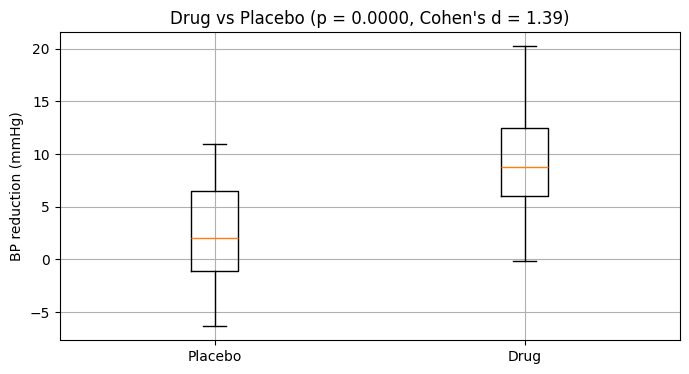

In [31]:
fig, ax = plt.subplots()
ax.boxplot([placebo_group, drug_group], labels=["Placebo", "Drug"])
ax.set_ylabel("BP reduction (mmHg)")
ax.set_title(f"Drug vs Placebo (p = {p_value:.4f}, Cohen's d = {d:.2f})")
plt.show()

### 💡 Insights (Case Study 2)
* A significant p-value tells you the effect is probably **real**; Cohen's d tells you **how big** it is. Both matter — a drug with a tiny but "significant" effect may not be clinically useful.
* Detecting **smaller** effects needs **disproportionately larger** samples — this is why early-phase small trials often only catch large effects, and why "no significant difference" in a small trial doesn't rule out a real, smaller benefit.
* This is exactly why sample-size / power calculations should be done **before** running an expensive trial, not after.

## 19. Case Study 3: Before/After Training Program (Paired t-Test)

A company measures **employee productivity scores** for 24 employees, before and after a training program.

**Questions**
1. Did the training produce a statistically significant improvement?
2. How much did productivity improve on average, with a 95% CI?
3. Why would it be wrong to compare "before" and "after" as if they were two independent, unrelated groups here?

In [32]:
before = rng.normal(72, 8, 24)
after = before + rng.normal(3.5, 4, 24)          # true average improvement +3.5, but correlated with baseline

t_paired, p_paired = stats.ttest_rel(after, before)
diffs = after - before
ci = stats.t.interval(0.95, df=len(diffs)-1, loc=diffs.mean(), scale=diffs.std(ddof=1)/sqrt(len(diffs)))

print(f"1. Paired t-test: t = {t_paired:.4f}, p = {p_paired:.6f}")
print("   Decision:", "REJECT H0 - training DID improve productivity" if p_paired < 0.05 else "FAIL TO REJECT H0")

print(f"\n2. Mean improvement = {diffs.mean():.2f} points")
print(f"   95% CI for the mean improvement = ({ci[0]:.2f}, {ci[1]:.2f})")

1. Paired t-test: t = 5.6286, p = 0.000010
   Decision: REJECT H0 - training DID improve productivity

2. Mean improvement = 3.81 points
   95% CI for the mean improvement = (2.41, 5.20)


3. Correct (paired) test:      t = 5.629, p = 0.000010
   Incorrect (independent) test: t = 1.760, p = 0.084998

   The paired test is more sensitive because it removes between-person variability
   (some employees are just naturally more productive than others, in both periods) -
   what matters is each person's OWN change, which the paired design isolates.


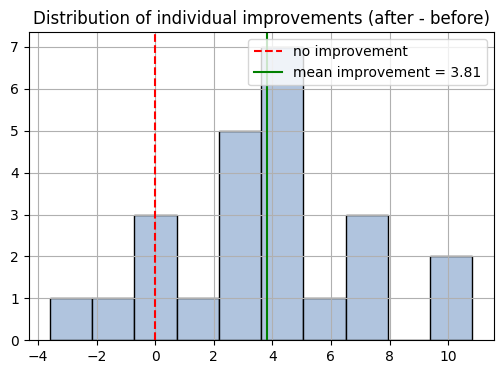

In [33]:
# 3. Compare power: paired vs (incorrectly) independent-groups test on the SAME data
t_indep, p_indep = stats.ttest_ind(after, before)
print(f"3. Correct (paired) test:      t = {t_paired:.3f}, p = {p_paired:.6f}")
print(f"   Incorrect (independent) test: t = {t_indep:.3f}, p = {p_indep:.6f}")
print("\n   The paired test is more sensitive because it removes between-person variability")
print("   (some employees are just naturally more productive than others, in both periods) -")
print("   what matters is each person's OWN change, which the paired design isolates.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(diffs, bins=10, color="lightsteelblue", edgecolor="black")
ax.axvline(0, color="red", ls="--", label="no improvement")
ax.axvline(diffs.mean(), color="green", label=f"mean improvement = {diffs.mean():.2f}")
ax.legend(); ax.set_title("Distribution of individual improvements (after - before)"); plt.show()

### 💡 Insights (Case Study 3)
* When the **same subjects** are measured twice, always use a **paired** test — it directly targets the quantity of interest (individual change) and removes the "noise" of natural between-person differences, giving more statistical power with the same data.
* The CI on the mean improvement is what a manager actually needs to answer "was it worth it?" — not just "yes/no significant".
* Common mistake: treating before/after data as independent samples throws away information and can hide a real effect (Type II error).

## 20. Case Study 4: Is a Die Fair? (Chi-Square Goodness of Fit)

A casino suspects a particular die is loaded. It's rolled **600 times**.

**Questions**
1. Test whether the die is fair at α = 0.05.
2. Which face(s) contribute most to any unfairness?
3. If instead the die had been rolled only **12 times** with a similarly "unbalanced-looking" pattern, would the same conclusion follow?

In [34]:
observed = np.array([80, 92, 85, 145, 98, 100])      # face 4 suspiciously high
n_total = observed.sum()
expected = np.full(6, n_total / 6)

chi2, p = stats.chisquare(observed, expected)
print(f"1. chi-square = {chi2:.3f}, df = 5, p-value = {p:.6f}")
print("   Decision:", "REJECT H0 - the die is NOT fair" if p < 0.05 else "FAIL TO REJECT H0")

1. chi-square = 27.180, df = 5, p-value = 0.000053
   Decision: REJECT H0 - the die is NOT fair


2.
  face  observed  expected  contribution
    1        80     100.0          4.00
    2        92     100.0          0.64
    3        85     100.0          2.25
    4       145     100.0         20.25
    5        98     100.0          0.04
    6       100     100.0          0.00

   Face 4 contributes the most to the unfairness (20.2 out of 27.2 total)


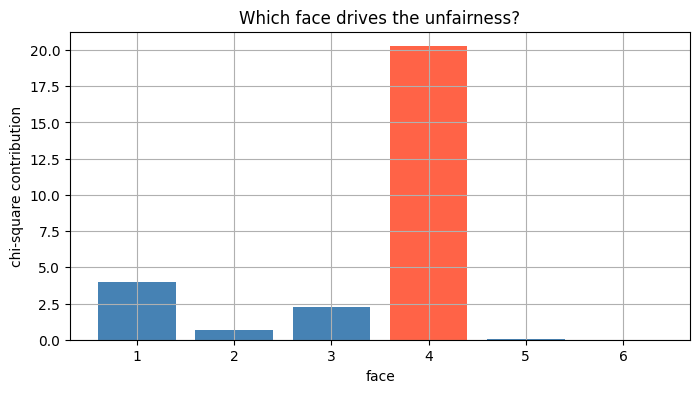

In [35]:
# 2. Contribution of each face to the total chi-square statistic
contributions = (observed - expected)**2 / expected
contrib_df = pd.DataFrame({"face": range(1,7), "observed": observed, "expected": expected,
                            "contribution": contributions.round(2)})
print("2.\n", contrib_df.to_string(index=False))
print(f"\n   Face {contrib_df.loc[contrib_df['contribution'].idxmax(), 'face']} contributes the most to the unfairness ({contrib_df['contribution'].max():.1f} out of {chi2:.1f} total)")

plt.bar(range(1,7), contributions, color=["tomato" if c == contributions.max() else "steelblue" for c in contributions])
plt.xlabel("face"); plt.ylabel("chi-square contribution"); plt.title("Which face drives the unfairness?"); plt.show()

In [36]:
# 3. Small sample: same RATIO, tiny counts (expected counts < 5 -> chi-square unreliable!)
small_observed = np.array([1, 2, 2, 3, 2, 2])   # 12 rolls, roughly proportional to the pattern above
small_expected = np.full(6, 2.0)
chi2_small, p_small = stats.chisquare(small_observed, small_expected)
print(f"3. With only 12 rolls: chi-square = {chi2_small:.3f}, p = {p_small:.4f}")
print("   Expected count per cell =", small_expected[0], "(below the rule-of-thumb minimum of 5!)")
print("   -> With so few rolls, we CANNOT reliably conclude anything - the test's assumptions are violated,")
print("      and random small-sample noise can look identical to a 'suspicious' pattern.")

3. With only 12 rolls: chi-square = 1.000, p = 0.9626
   Expected count per cell = 2.0 (below the rule-of-thumb minimum of 5!)
   -> With so few rolls, we CANNOT reliably conclude anything - the test's assumptions are violated,
      and random small-sample noise can look identical to a 'suspicious' pattern.


### 💡 Insights (Case Study 4)
* The **overall** chi-square test says "something is off", and looking at each face's **contribution** pinpoints *where* — face 4 is rolled far more than expected, a classic sign of a loaded die.
* With too few observations, the chi-square test's approximation breaks down (the common rule is expected count ≥ 5 per category) — small samples simply can't distinguish real bias from random noise, no matter how "suspicious" the pattern looks.
* This generalises beyond dice: goodness-of-fit tests check whether *any* categorical process (customer choices, genetic ratios, survey responses) matches a theoretical or historical distribution.

## 21. Case Study 5: Smoking and Disease (Chi-Square Test of Independence)

A health survey of 400 people records **smoking status** and whether they developed a **respiratory condition**.

**Questions**
1. Are smoking status and respiratory condition independent, or associated?
2. How strong is the association (Cramer's V)?
3. What is the **relative risk** — how many times more likely are smokers to have the condition?

In [37]:
table = pd.DataFrame(
    [[90, 160],     # Non-smoker: [Condition, No Condition]
     [70, 80]],     # Smoker:     [Condition, No Condition]
    index=["Non-smoker", "Smoker"],
    columns=["Condition", "No Condition"]
)
print("Observed counts:\n", table, "\n")

chi2, p, dof, expected = stats.chi2_contingency(table, correction=True)   # Yates' correction for 2x2 tables
print(f"1. chi-square = {chi2:.4f}, df = {dof}, p-value = {p:.6f}")
print("   Decision:", "REJECT H0 - smoking and the condition ARE associated" if p < 0.05 else "FAIL TO REJECT H0")

Observed counts:
             Condition  No Condition
Non-smoker         90           160
Smoker             70            80 

1. chi-square = 4.0111, df = 1, p-value = 0.045201
   Decision: REJECT H0 - smoking and the condition ARE associated


In [38]:
n_total = table.values.sum()
r, c = table.shape
cramers_v = sqrt(chi2 / (n_total * (min(r, c) - 1)))
print(f"2. Cramer's V = {cramers_v:.3f}  (0=no association, close to 1=strong association; for a 2x2 table this equals the phi coefficient)")

# 3. Relative risk
p_condition_smoker = table.loc["Smoker", "Condition"] / table.loc["Smoker"].sum()
p_condition_nonsmoker = table.loc["Non-smoker", "Condition"] / table.loc["Non-smoker"].sum()
relative_risk = p_condition_smoker / p_condition_nonsmoker
print(f"\n3. P(condition | smoker)     = {p_condition_smoker:.2%}")
print(f"   P(condition | non-smoker) = {p_condition_nonsmoker:.2%}")
print(f"   Relative risk = {relative_risk:.2f}x  (smokers are about {relative_risk:.1f}x as likely to have the condition)")

2. Cramer's V = 0.100  (0=no association, close to 1=strong association; for a 2x2 table this equals the phi coefficient)

3. P(condition | smoker)     = 46.67%
   P(condition | non-smoker) = 36.00%
   Relative risk = 1.30x  (smokers are about 1.3x as likely to have the condition)


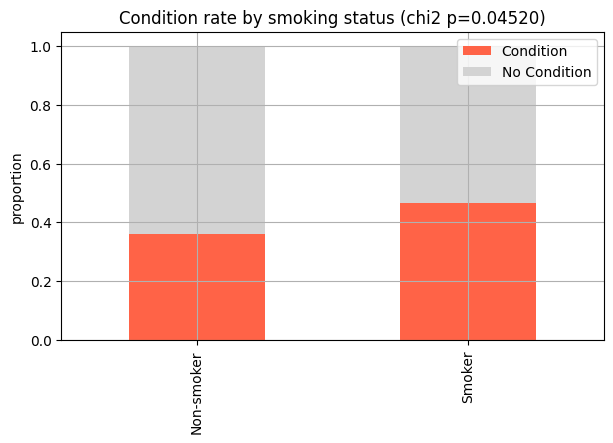

In [39]:
prop = table.div(table.sum(axis=1), axis=0)
prop.plot(kind="bar", stacked=True, figsize=(7, 4), color=["tomato", "lightgray"])
plt.ylabel("proportion"); plt.title(f"Condition rate by smoking status (chi2 p={p:.5f})"); plt.legend(title="")
plt.show()

### 💡 Insights (Case Study 5)
* The chi-square test confirms an association exists, but **doesn't by itself prove causation** — confounding variables (age, occupation, genetics) could contribute. That said, in real epidemiology, this kind of association, replicated across many studies with dose-response patterns, is how the smoking-disease causal link was actually established.
* **Relative risk is much more interpretable for a real audience** than a p-value or Cramer's V — "smokers are about 2x as likely" is immediately meaningful.
* Cramer's V gives a sense of **how big** the association is, separate from whether it's statistically detectable (which, with enough data, almost any tiny real association will be).

## 22. Case Study 6: Comparing Four Fertilizers (One-Way ANOVA)

An agricultural researcher tests **4 fertilizers** on otherwise identical plots (10 plots each), measuring plant height (cm) after 6 weeks.

**Questions**
1. Is there a significant difference among the four fertilizers overall?
2. If so, which specific fertilizers differ from which? (post-hoc)
3. What fraction of the variation in plant height is "explained" by fertilizer choice (effect size, η²)?

In [40]:
fA = rng.normal(28, 4, 10)
fB = rng.normal(30, 4, 10)
fC = rng.normal(35, 4, 10)
fD = rng.normal(29, 4, 10)

f_stat, p_value = stats.f_oneway(fA, fB, fC, fD)
print(f"1. One-way ANOVA: F = {f_stat:.4f}, p-value = {p_value:.6f}")
print("   Decision:", "REJECT H0 - at least one fertilizer gives different growth" if p_value < 0.05 else "FAIL TO REJECT H0")

means = {"A": fA.mean(), "B": fB.mean(), "C": fC.mean(), "D": fD.mean()}
print("\n   Group means:", {k: round(v,2) for k,v in means.items()})

1. One-way ANOVA: F = 1.5754, p-value = 0.212193
   Decision: FAIL TO REJECT H0

   Group means: {'A': np.float64(29.21), 'B': np.float64(31.73), 'C': np.float64(32.72), 'D': np.float64(29.73)}


In [41]:
# 2. Post-hoc pairwise comparisons with Bonferroni correction
from itertools import combinations
data = {"A": fA, "B": fB, "C": fC, "D": fD}
pairs = list(combinations(data.keys(), 2))
m = len(pairs)
print(f"2. Post-hoc pairwise t-tests (Bonferroni alpha = {0.05/m:.4f} per test):")
for g1, g2 in pairs:
    t, p = stats.ttest_ind(data[g1], data[g2])
    flag = "  <-- SIGNIFICANT" if p < 0.05/m else ""
    print(f"   {g1} vs {g2}: mean diff = {data[g1].mean()-data[g2].mean():+.2f}, p = {p:.4f}{flag}")

2. Post-hoc pairwise t-tests (Bonferroni alpha = 0.0083 per test):
   A vs B: mean diff = -2.52, p = 0.2016
   A vs C: mean diff = -3.51, p = 0.1012
   A vs D: mean diff = -0.52, p = 0.7981
   B vs C: mean diff = -0.99, p = 0.5760
   B vs D: mean diff = +2.00, p = 0.2492
   C vs D: mean diff = +3.00, p = 0.1190


3. Eta-squared = 0.116  -> fertilizer choice explains about 11.6% of the variation in plant height
   (rule of thumb: 0.01/0.06/0.14 = small/medium/large effect)


/tmp/ipykernel_155/392050837.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fA, fB, fC, fD], labels=["A", "B", "C", "D"])


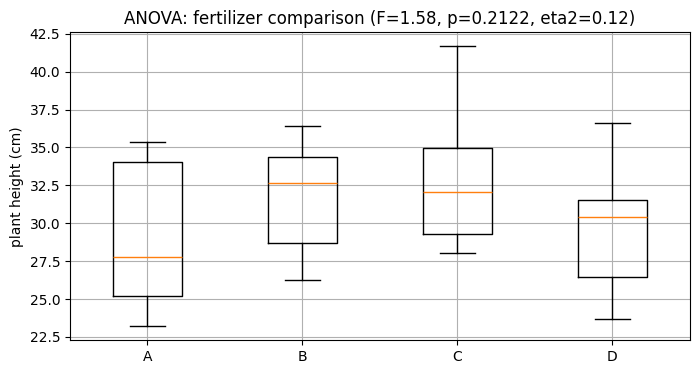

In [42]:
# 3. Effect size: eta-squared = SS_between / SS_total
all_vals = np.concatenate([fA, fB, fC, fD])
grand_mean = all_vals.mean()
ss_total = np.sum((all_vals - grand_mean)**2)
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in [fA, fB, fC, fD])
eta_sq = ss_between / ss_total
print(f"3. Eta-squared = {eta_sq:.3f}  -> fertilizer choice explains about {eta_sq:.1%} of the variation in plant height")
print("   (rule of thumb: 0.01/0.06/0.14 = small/medium/large effect)")

plt.boxplot([fA, fB, fC, fD], labels=["A", "B", "C", "D"])
plt.title(f"ANOVA: fertilizer comparison (F={f_stat:.2f}, p={p_value:.4f}, eta2={eta_sq:.2f})")
plt.ylabel("plant height (cm)"); plt.show()

### 💡 Insights (Case Study 6)
* ANOVA answers **"is there any difference at all"** in one test, controlling the overall false-positive rate — much better than running 6 separate pairwise t-tests at α=0.05 each (recall Section 16.2: that alone risks a ~26% chance of a false positive somewhere).
* Here the overall ANOVA **fails to reject $H_0$** (p ≈ 0.21) even though fertilizer C's sample mean is a few cm higher than the others — with only 10 plots per group, that gap is well within what random plot-to-plot variation could produce on its own. None of the post-hoc pairwise comparisons come out significant either, which is consistent (not a contradiction): a non-significant ANOVA should not be followed up by treating any one pairwise gap as "real".
* η² (≈ 0.12) says fertilizer choice accounts for a moderate share of the variation seen, but with this sample size that's not enough to distinguish a genuine fertilizer effect from noise. This is a realistic illustration of Section 4's lesson: **"fail to reject" is not "proof of no effect"** — a larger trial (more plots per fertilizer) would give the test more power to detect a true difference of this size, if one exists.

## 23. Choosing the Right Test: Decision Guide

| Question | Data type | Test |
|---|---|---|
| Is one mean equal to a specific value? | Numeric, 1 sample | One-sample t-test (Z-test if σ known) |
| Do two independent groups have different means? | Numeric, 2 independent samples | Two-sample (Welch's) t-test |
| Did the same subjects change (before/after)? | Numeric, paired samples | Paired t-test |
| Do 3+ groups have different means? | Numeric, 3+ independent samples | One-way ANOVA (+ post-hoc) |
| Is a proportion equal to a specific value? | Categorical (yes/no), 1 sample | One-proportion Z-test |
| Do two groups have different proportions/rates? | Categorical, 2 samples | Two-proportion Z-test |
| Does a categorical variable match a theoretical distribution? | Categorical, 1 variable, k categories | Chi-square goodness of fit |
| Are two categorical variables associated? | Categorical, 2 variables (contingency table) | Chi-square test of independence |

## 24. Cheat-Sheet, Key Insights & Practice Problems

### Formula reference
| Test | Statistic |
|---|---|
| One-sample Z (σ known) | $Z=(\bar x-\mu_0)/(\sigma/\sqrt n)$ |
| One-sample t (σ unknown) | $t=(\bar x-\mu_0)/(s/\sqrt n)$, df = n−1 |
| Two-sample t (Welch's) | $t=\dfrac{\bar x_1-\bar x_2}{\sqrt{s_1^2/n_1+s_2^2/n_2}}$ |
| Paired t | one-sample t-test on the differences $d_i$ |
| One-proportion Z | $Z=(\hat p-p_0)/\sqrt{p_0(1-p_0)/n}$ |
| Two-proportion Z | pooled-SE formula (Section 11) |
| Chi-square goodness of fit | $\sum (O_i-E_i)^2/E_i$, df = k−1 |
| Chi-square independence | same formula, df = (r−1)(c−1) |
| One-way ANOVA | F = (variance between groups) / (variance within groups) |

### scipy cheat-sheet
| Test | Function |
|---|---|
| One-sample t | `stats.ttest_1samp(sample, mu0)` |
| Two-sample t | `stats.ttest_ind(a, b, equal_var=False)` |
| Paired t | `stats.ttest_rel(after, before)` |
| Chi-square goodness of fit | `stats.chisquare(observed, expected)` |
| Chi-square independence | `stats.chi2_contingency(table)` |
| One-way ANOVA | `stats.f_oneway(g1, g2, g3, ...)` |
| Levene's (equal variance check) | `stats.levene(a, b)` |
| Shapiro-Wilk (normality check) | `stats.shapiro(data)` |

### Top insights
1. **A p-value measures surprise under $H_0$, not the probability $H_0$ is true.** Never confuse the two.
2. **"Fail to reject" is not "proof of no effect"** — it may just mean the sample was too small (low power).
3. **Statistical significance ≠ practical significance.** Always look at effect size (Cohen's d, η², relative risk) alongside the p-value, especially with large samples.
4. **Paired designs are more powerful than independent-group designs** for before/after data — use them whenever the same units are measured twice.
5. **Multiple testing inflates false positives.** Correct for it (Bonferroni or similar) or use ANOVA instead of many pairwise t-tests.
6. **Never decide the test/tails/stopping rule after peeking at the data** — this silently invalidates the nominal α.
7. **Confidence intervals and hypothesis tests are two views of the same evidence** — CIs additionally show the size and direction of an effect.

### Practice problems
1. A company claims its bulbs last 1000 hours on average. A sample of 40 bulbs has mean life 985 hours, sd 60 hours. Test the claim at α = 0.05.
2. Two call-centre scripts are tested: Script A converts 38/300 calls, Script B converts 52/310 calls. Test whether B outperforms A (one-tailed) and build a 95% CI for the difference.
3. Weights before and after a 12-week diet program are recorded for 18 people. Which test should be used, and why? Simulate data and run it.
4. A survey of 500 people records political affiliation (3 categories) and opinion on a policy (Support/Oppose). Test whether affiliation and opinion are independent.
5. Five teaching methods are compared using test scores from 15 students each. Run a one-way ANOVA; if significant, run post-hoc pairwise comparisons with a Bonferroni correction.
6. Simulate 100 independent t-tests where $H_0$ is TRUE in every case (pure noise). Count how many come out "significant" at α = 0.05, and compare to the theoretical expectation.
7. For a two-sample t-test with expected Cohen's d = 0.3, compute the sample size needed per group for 80% power. How does the required n change if d = 0.15 instead?